#  Yassir AI Market Challenge - Product Recommendation System

##  Overview
This notebook implements a comprehensive product recommendation system for the Yassir AI Market Challenge. The approach combines:
- **Feature Engineering**: User-product interactions, recency, frequency, and popularity metrics
- **Scoring System**: Weighted scoring with multiple boosting strategies
- **Cold-Start Handling**: Popular product recommendations for new users

##  Challenge Goal
Predict the top 10 products each user is likely to purchase in their next order based on historical purchase data.

---

---

##  What Type of Recommendation System is This?

This notebook implements a **hybrid rule-based recommendation system** with the following characteristics:

- **Personalized**: Uses user-product interaction history, recency, frequency, and user-specific reorder rates.
- **Content-based**: Leverages user and product features (not just collaborative filtering).
- **Popularity-based fallback**: For cold-start users, recommends globally popular products.
- **No ML model**: All logic is based on engineered features and weighted scoring, not a trained machine learning model.

**Summary:**
> This is a feature-engineered, rule-based, hybrid recommender system that combines personalized, content-based, and popularity-based strategies for robust product recommendations.

##  1. Import Libraries & Setup

In [1]:
# Import essential libraries
import pandas as pd
import numpy as np
import pickle
import warnings
import time
from datetime import datetime

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

print("="*80)
print(" "*20 + " YASSIR RECOMMENDATION SYSTEM")
print("="*80)
print(f" Execution Time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*80)

                     YASSIR RECOMMENDATION SYSTEM
 Execution Time: 2025-10-17 12:08:09


##  2. Configuration Settings

Configure all parameters for data paths, feature engineering, and model tuning.

In [2]:
CONFIG = {
    # ============================================================================
    # DATA PATHS
    # ============================================================================
    'data_path': '/kaggle/input/yassir-ai-market-challenge/yassir_marekt_data_09_2025/yassir_marekt_data_09_2025 2/',
    'test_file': '/kaggle/input/yassir-ai-market-challenge/test_new_version.csv',
    'save_path': 'trained_models_final.pkl',
    'output_path': 'submission.csv',
    
    # ============================================================================
    # FEATURE ENGINEERING PARAMETERS
    # ============================================================================
    'recency_decay': 0.2,          # Exponential decay rate for recency (lower = slower decay)
    'frequency_cap': 10,            # Cap for normalizing order frequency
    
    # ============================================================================
    # SCORING WEIGHTS (Must sum to ~1.0)
    # ============================================================================
    'weights': {
        'recency': 0.25,           # Recent purchase importance
        'frequency': 0.15,         # Order frequency importance
        'reorder_rate': 0.20,      # User's tendency to reorder
        'popularity': 0.10,        # Product popularity
        'user_habit': 0.30         # User's overall reorder behavior
    },
    
    # ============================================================================
    # BOOST MULTIPLIERS
    # ============================================================================
    'boosts': {
        'recent_order_0': 1.5,     # Last order boost
        'recent_order_1': 1.3,     # 2nd last order boost
        'recent_order_2': 1.15,    # 3rd last order boost
        'freq_5_orders': 1.2,      # Ordered 5+ times
        'freq_10_orders': 1.3,     # Ordered 10+ times
        'perfect_reorder': 1.15,   # 100% reorder rate
        'high_frequency': 1.1      # High order frequency (>0.5)
    },
    
    # ============================================================================
    # PREDICTION PARAMETERS
    # ============================================================================
    'top_n': 10,                   # Number of products to recommend per user
    'score_threshold': 0.10,       # Minimum score for recommendation
    'popular_products': 30,        # Number of popular products for cold-start
}

print("✅ Configuration loaded successfully!")
print(f"\n📊 Key Settings:")
print(f"   - Top N recommendations: {CONFIG['top_n']}")
print(f"   - Score threshold: {CONFIG['score_threshold']}")
print(f"   - Recency decay rate: {CONFIG['recency_decay']}")
print(f"\n⚖️ Scoring Weights:")
for key, val in CONFIG['weights'].items():
    print(f"   - {key}: {val}")

✅ Configuration loaded successfully!

📊 Key Settings:
   - Top N recommendations: 10
   - Score threshold: 0.1
   - Recency decay rate: 0.2

⚖️ Scoring Weights:
   - recency: 0.25
   - frequency: 0.15
   - reorder_rate: 0.2
   - popularity: 0.1
   - user_habit: 0.3


##  3. Load Data

Load all required datasets from the data directory.

In [3]:
print("\n" + "="*80)
print(" LOADING DATASETS")
print("="*80)

start_time = time.time()
base_path = CONFIG['data_path']

# Load all datasets
orders = pd.read_csv(base_path + 'orders_df.csv')
order_products = pd.read_csv(base_path + 'orders_products_df.csv')
products = pd.read_csv(base_path + 'products_df.csv')
users = pd.read_csv(base_path + 'users_df.csv')
user_test = pd.read_csv(CONFIG['test_file'])

load_time = time.time() - start_time

print(f"\n All datasets loaded in {load_time:.2f}s")
print(f"\n Dataset Shapes:")
print(f"   • Orders:         {orders.shape[0]:>10,} rows × {orders.shape[1]:>2} columns")
print(f"   • Order-Products: {order_products.shape[0]:>10,} rows × {order_products.shape[1]:>2} columns")
print(f"   • Products:       {products.shape[0]:>10,} rows × {products.shape[1]:>2} columns")
print(f"   • Users (ALL):    {users.shape[0]:>10,} rows × {users.shape[1]:>2} columns")
print(f"   • Test Users:     {user_test.shape[0]:>10,} rows × {user_test.shape[1]:>2} columns")

print(f"\n📈 Key Metrics:")
print(f"   • Unique users with orders: {orders['user_id'].nunique():,}")
print(f"   • Unique products: {order_products['product_id'].nunique():,}")
print(f"   • Total order-product pairs: {len(order_products):,}")


 LOADING DATASETS

 All datasets loaded in 19.32s

 Dataset Shapes:
   • Orders:          3,193,704 rows ×  6 columns
   • Order-Products: 31,536,952 rows ×  4 columns
   • Products:           49,688 rows ×  3 columns
   • Users (ALL):       206,209 rows ×  3 columns
   • Test Users:         75,486 rows ×  1 columns

📈 Key Metrics:
   • Unique users with orders: 206,209
   • Unique products: 49,668
   • Total order-product pairs: 31,536,952


### 3.1 Exploratory Data Analysis (EDA)

Let's explore the main dataframes: orders, order_products, products, users, and user_test. We'll print their heads, shapes, and info for a quick overview.

In [4]:
# Print summary and head for each main dataframe
def print_df_info(df, name):
    print(f"\n{'='*40}\n{name} DataFrame\n{'='*40}")
    print(f"Shape: {df.shape}")
    print(df.head())
    print("\nInfo:")
    print(df.info())
    print("\nDescribe (numeric):")
    print(df.describe(include='number'))
    print("\nColumns:", df.columns.tolist())

print_df_info(orders, "orders")
print_df_info(order_products, "order_products")
print_df_info(products, "products")
print_df_info(users, "users")
print_df_info(user_test, "user_test")


orders DataFrame
Shape: (3193704, 6)
   order_id  user_id  order_number order_day  order_hour  \
0   2539329        1             1    Sunday           8   
1   2398795        1             2    Monday           7   
2    473747        1             3    Monday          12   
3   2254736        1             4   Tuesday           7   
4    431534        1             5   Tuesday          15   

   days_since_last_order  
0                    NaN  
1                   15.0  
2                   21.0  
3                   29.0  
4                   28.0  

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3193704 entries, 0 to 3193703
Data columns (total 6 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   order_id               int64  
 1   user_id                int64  
 2   order_number           int64  
 3   order_day              object 
 4   order_hour             int64  
 5   days_since_last_order  float64
dtypes: float64(1), int64(4), ob

#### 📈 3.3 Visual EDA: Plots for Main DataFrames

Below are some useful plots to understand the data distributions and relationships.

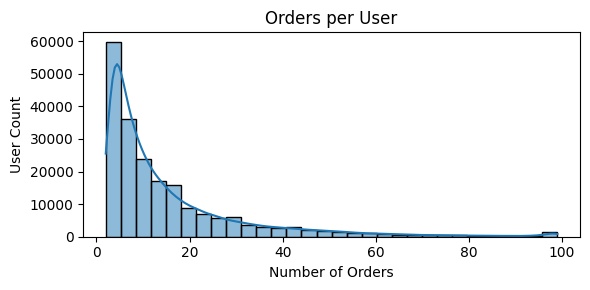

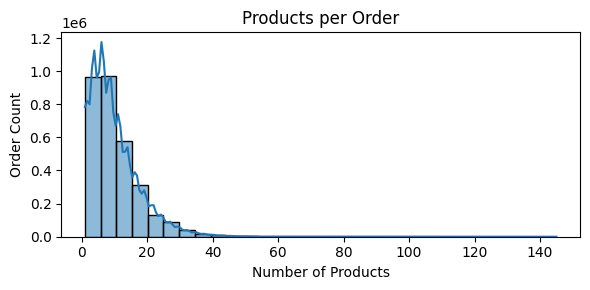

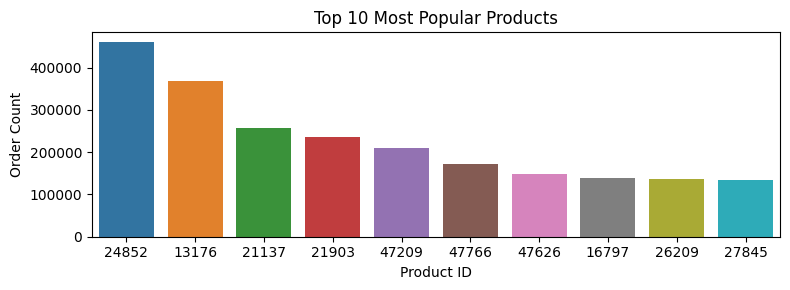

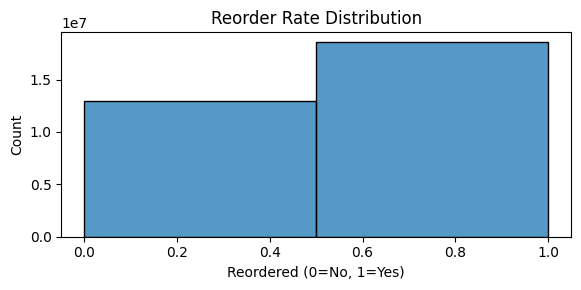

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Orders per user
g = orders.groupby('user_id')['order_id'].count()
plt.figure(figsize=(6,3))
sns.histplot(g, bins=30, kde=True)
plt.title('Orders per User')
plt.xlabel('Number of Orders')
plt.ylabel('User Count')
plt.tight_layout()
plt.show()

# Products per order
g2 = order_products.groupby('order_id')['product_id'].count()
plt.figure(figsize=(6,3))
sns.histplot(g2, bins=30, kde=True)
plt.title('Products per Order')
plt.xlabel('Number of Products')
plt.ylabel('Order Count')
plt.tight_layout()
plt.show()

# Top 10 most popular products
pop = order_products['product_id'].value_counts().head(10)
plt.figure(figsize=(8,3))
sns.barplot(x=pop.index.astype(str), y=pop.values)
plt.title('Top 10 Most Popular Products')
plt.xlabel('Product ID')
plt.ylabel('Order Count')
plt.tight_layout()
plt.show()

# Reorder rate distribution
plt.figure(figsize=(6,3))
sns.histplot(order_products['reordered'], bins=2)
plt.title('Reorder Rate Distribution')
plt.xlabel('Reordered (0=No, 1=Yes)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

###  3.2 Additional EDA: Key Distributions & Visuals

- Distribution of orders per user
- Distribution of products per order
- Top 10 most popular products
- Reorder rate distribution

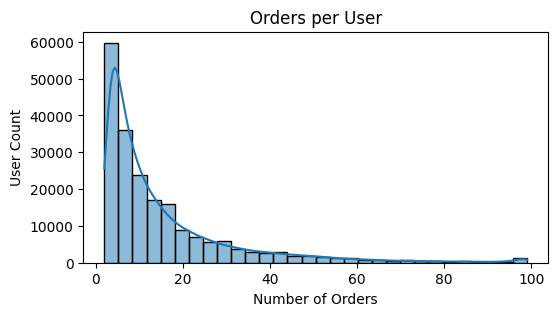

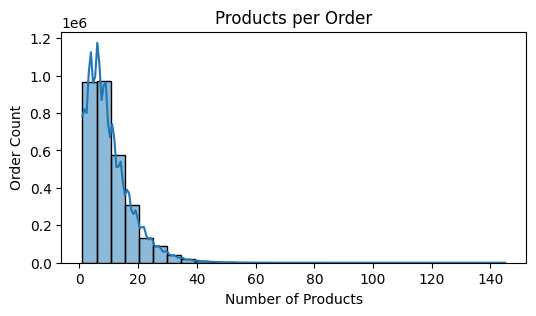

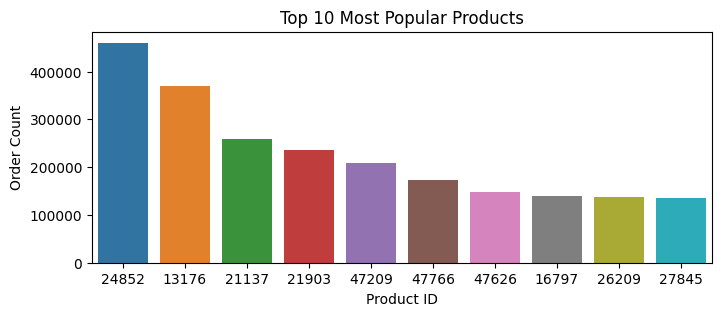

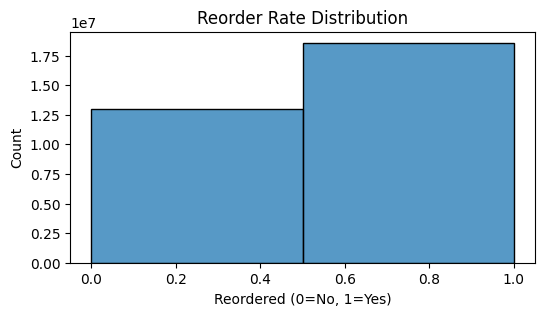

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Orders per user
g = orders.groupby('user_id')['order_id'].count()
plt.figure(figsize=(6,3))
sns.histplot(g, bins=30, kde=True)
plt.title('Orders per User')
plt.xlabel('Number of Orders')
plt.ylabel('User Count')
plt.show()

# Products per order
g2 = order_products.groupby('order_id')['product_id'].count()
plt.figure(figsize=(6,3))
sns.histplot(g2, bins=30, kde=True)
plt.title('Products per Order')
plt.xlabel('Number of Products')
plt.ylabel('Order Count')
plt.show()

# Top 10 most popular products
pop = order_products['product_id'].value_counts().head(10)
plt.figure(figsize=(8,3))
sns.barplot(x=pop.index.astype(str), y=pop.values)
plt.title('Top 10 Most Popular Products')
plt.xlabel('Product ID')
plt.ylabel('Order Count')
plt.show()

# Reorder rate distribution
plt.figure(figsize=(6,3))
sns.histplot(order_products['reordered'], bins=2)
plt.title('Reorder Rate Distribution')
plt.xlabel('Reordered (0=No, 1=Yes)')
plt.ylabel('Count')
plt.show()

##  4. Data Preparation

Merge datasets to create a unified order-products dataframe with all necessary information.

In [7]:
print("\n" + "="*80)
print(" DATA PREPARATION")
print("="*80)

# Add user_id and order_number to order_products if not present
if 'user_id' not in order_products.columns:
    print("\n   Merging user_id into order_products...")
    order_products = order_products.merge(
        orders[['order_id', 'user_id', 'order_number']], 
        on='order_id', 
        how='left'
    )

# Add product category information
print("   Adding product category information...")
order_products = order_products.merge(
    products[['product_id', 'category_id', 'sub_category_id']], 
    on='product_id', 
    how='left'
)

print(f"\n Data preparation complete!")
print(f"   • Total rows: {len(order_products):,}")
print(f"   • Unique users: {order_products['user_id'].nunique():,}")
print(f"   • Unique products: {order_products['product_id'].nunique():,}")
print(f"   • Memory usage: {order_products.memory_usage(deep=True).sum() / 1024**2:.1f} MB")


 DATA PREPARATION

   Merging user_id into order_products...
   Adding product category information...

 Data preparation complete!
   • Total rows: 31,536,952
   • Unique users: 206,209
   • Unique products: 49,668
   • Memory usage: 1924.9 MB


###  4.1 EDA on Merged DataFrame

Let's explore the merged `order_products` dataframe and print the first 5 rows of each main dataframe for a quick overview.

In [8]:
# Print first 5 rows of each main dataframe after merging
print("\nFirst 5 rows of merged order_products:")
print(order_products.head())

print("\nFirst 5 rows of orders:")
print(orders.head())

print("\nFirst 5 rows of products:")
print(products.head())

print("\nFirst 5 rows of users:")
print(users.head())

print("\nFirst 5 rows of user_test:")
print(user_test.head())


First 5 rows of merged order_products:
   order_id  product_id  add_to_cart_order  reordered  user_id  order_number  \
0         2       33120                  1          1   202279             3   
1         2       28985                  2          1   202279             3   
2         2        9327                  3          0   202279             3   
3         2       45918                  4          1   202279             3   
4         2       30035                  5          0   202279             3   

   category_id  sub_category_id  
0           16               86  
1            4               83  
2           13              104  
3           13               19  
4           13               17  

First 5 rows of orders:
   order_id  user_id  order_number order_day  order_hour  \
0   2539329        1             1    Sunday           8   
1   2398795        1             2    Monday           7   
2    473747        1             3    Monday          12   
3   225473

##  5. Feature Engineering

### Approach: Comprehensive Multi-Level Feature Engineering

We'll create features at three levels:
1. **User-Product Level**: Interaction patterns between specific users and products
2. **User Level**: Overall user behavior and preferences
3. **Product Level**: Product popularity and characteristics

This approach captures:
- **Recency**: How recently a product was purchased
- **Frequency**: How often a product is purchased
- **Reorder Behavior**: User and product reorder patterns
- **Popularity**: Global product trends

### 5.1 User-Product Interaction Features

In [9]:
print("\n" + "="*80)
print("  FEATURE ENGINEERING - PHASE 1: USER-PRODUCT FEATURES")
print("="*80)

start_time = time.time()

# Aggregate user-product interactions
up_features = order_products.groupby(['user_id', 'product_id']).agg({
    'order_id': 'count',                    # Total times user ordered this product
    'order_number': ['min', 'max', 'mean'], # First order, last order, average order
    'reordered': ['sum', 'mean'],           # Total reorders, reorder rate
    'add_to_cart_order': ['mean', 'min']    # Average cart position, first cart position
}).reset_index()

# Flatten column names
up_features.columns = [
    'user_id', 'product_id', 
    'up_order_count',           # How many times ordered
    'up_first_order',           # First time ordered (order number)
    'up_last_order',            # Last time ordered (order number)
    'up_mean_order',            # Average order number
    'up_reorder_count',         # Number of times reordered
    'up_reorder_rate',          # Reorder rate (0-1)
    'up_avg_cart_pos',          # Average position in cart
    'up_min_cart_pos'           # Earliest position in cart
]

phase1_time = time.time() - start_time

print(f"\n Phase 1 complete in {phase1_time:.2f}s")
print(f"   • User-product pairs: {len(up_features):,}")
print(f"   • Features created: 8")
print(f"\n Sample Statistics:")
print(f"   • Avg orders per user-product: {up_features['up_order_count'].mean():.2f}")
print(f"   • Max orders for single product: {up_features['up_order_count'].max()}")
print(f"   • Avg reorder rate: {up_features['up_reorder_rate'].mean():.3f}")


  FEATURE ENGINEERING - PHASE 1: USER-PRODUCT FEATURES

 Phase 1 complete in 34.55s
   • User-product pairs: 12,956,509
   • Features created: 8

 Sample Statistics:
   • Avg orders per user-product: 2.43
   • Max orders for single product: 99
   • Avg reorder rate: 0.265


### 5.2 Recency & Frequency Features

In [10]:
print("\n" + "="*80)
print(" FEATURE ENGINEERING - PHASE 2: RECENCY & FREQUENCY")
print("="*80)

start_time = time.time()

# Get each user's maximum order number (most recent order)
max_orders = order_products.groupby('user_id')['order_number'].max().reset_index()
max_orders.columns = ['user_id', 'user_max_order']

# Merge with user-product features
up_features = up_features.merge(max_orders, on='user_id', how='left')

# Calculate recency metrics
up_features['up_orders_since_last'] = up_features['user_max_order'] - up_features['up_last_order']
up_features['up_order_span'] = up_features['up_last_order'] - up_features['up_first_order'] + 1
up_features['up_order_frequency'] = up_features['up_order_count'] / up_features['up_order_span']

# Recency score: exponential decay (more recent purchases = higher score)
# Score ranges from 0 to 1, where 1 = purchased in last order
up_features['up_recency_score'] = np.exp(-CONFIG['recency_decay'] * up_features['up_orders_since_last'])

phase2_time = time.time() - start_time

print(f"\n Phase 2 complete in {phase2_time:.2f}s")
print(f"   • Features created: 5")
print(f"\n Recency Distribution:")
print(f"   • Products in last order: {(up_features['up_orders_since_last'] == 0).sum():,}")
print(f"   • Products in last 3 orders: {(up_features['up_orders_since_last'] <= 2).sum():,}")
print(f"   • Avg recency score: {up_features['up_recency_score'].mean():.3f}")
print(f"\n Frequency Distribution:")
print(f"   • Avg order frequency: {up_features['up_order_frequency'].mean():.3f}")
print(f"   • High frequency products (>0.5): {(up_features['up_order_frequency'] > 0.5).sum():,}")


 FEATURE ENGINEERING - PHASE 2: RECENCY & FREQUENCY

 Phase 2 complete in 3.23s
   • Features created: 5

 Recency Distribution:
   • Products in last order: 2,129,609
   • Products in last 3 orders: 4,854,303
   • Avg recency score: 0.453

 Frequency Distribution:
   • Avg order frequency: 0.807
   • High frequency products (>0.5): 9,989,146


### 5.3 User-Level Features

In [11]:
print("\n" + "="*80)
print(" FEATURE ENGINEERING - PHASE 3: USER-LEVEL FEATURES")
print("="*80)

start_time = time.time()

# Aggregate user-level behavior
user_features = order_products.groupby('user_id').agg({
    'order_id': 'nunique',              # Total unique orders
    'product_id': ['count', 'nunique'], # Total items purchased, unique products
    'reordered': 'mean'                 # Overall user reorder rate
}).reset_index()

# Flatten column names
user_features.columns = [
    'user_id', 
    'user_total_orders',        # Number of orders placed
    'user_total_items',         # Total items purchased
    'user_unique_products',     # Number of unique products
    'user_reorder_rate'         # User's reorder tendency
]

# Calculate derived metrics
user_features['user_avg_basket_size'] = user_features['user_total_items'] / user_features['user_total_orders']
user_features['user_exploration_rate'] = user_features['user_unique_products'] / user_features['user_total_items']

# Merge with user-product features
up_features = up_features.merge(user_features, on='user_id', how='left')

phase3_time = time.time() - start_time

print(f"\n Phase 3 complete in {phase3_time:.2f}s")
print(f"   • Features created: 6")
print(f"\n User Behavior Statistics:")
print(f"   • Avg orders per user: {user_features['user_total_orders'].mean():.2f}")
print(f"   • Avg basket size: {user_features['user_avg_basket_size'].mean():.2f}")
print(f"   • Avg unique products per user: {user_features['user_unique_products'].mean():.2f}")
print(f"   • Avg user reorder rate: {user_features['user_reorder_rate'].mean():.3f}")


 FEATURE ENGINEERING - PHASE 3: USER-LEVEL FEATURES

 Phase 3 complete in 13.45s
   • Features created: 6

 User Behavior Statistics:
   • Avg orders per user: 15.12
   • Avg basket size: 9.94
   • Avg unique products per user: 62.83
   • Avg user reorder rate: 0.422


### 5.4 Product-Level Features

In [12]:
print("\n" + "="*80)
print(" FEATURE ENGINEERING - PHASE 4: PRODUCT-LEVEL FEATURES")
print("="*80)

start_time = time.time()

# Aggregate product-level statistics
product_features = order_products.groupby('product_id').agg({
    'order_id': 'count',        # Total times product was ordered
    'user_id': 'nunique',       # Number of unique users who ordered
    'reordered': ['sum', 'mean'] # Total reorders, reorder rate
}).reset_index()

# Flatten column names
product_features.columns = [
    'product_id', 
    'prod_total_orders',        # Total times ordered across all users
    'prod_unique_users',        # How many users ordered this product
    'prod_total_reorders',      # Total reorder count
    'prod_reorder_rate'         # Product reorder likelihood
]

# Calculate popularity score
product_features['prod_popularity'] = (
    product_features['prod_total_orders'] / product_features['prod_unique_users']
)

# Merge with user-product features
up_features = up_features.merge(product_features, on='product_id', how='left')

# Clean up: Fill missing values and remove infinite values
up_features = up_features.fillna(0)
up_features = up_features.replace([np.inf, -np.inf], 0)

phase4_time = time.time() - start_time

print(f"\n Phase 4 complete in {phase4_time:.2f}s")
print(f"   • Features created: 5")
print(f"\n Product Popularity Statistics:")
print(f"   • Avg orders per product: {product_features['prod_total_orders'].mean():.2f}")
print(f"   • Avg users per product: {product_features['prod_unique_users'].mean():.2f}")
print(f"   • Avg product reorder rate: {product_features['prod_reorder_rate'].mean():.3f}")
print(f"   • Most popular product orders: {product_features['prod_total_orders'].max():,}")


 FEATURE ENGINEERING - PHASE 4: PRODUCT-LEVEL FEATURES

 Phase 4 complete in 18.53s
   • Features created: 5

 Product Popularity Statistics:
   • Avg orders per product: 634.96
   • Avg users per product: 260.86
   • Avg product reorder rate: 0.365
   • Most popular product orders: 460,257


### 5.5 Feature Engineering Summary

###  5.6 EDA on Feature DataFrame

Let's explore the engineered features and visualize relationships between key variables.


First 5 rows of up_features (engineered features):
   user_id  product_id  up_order_count  up_first_order  up_last_order  \
0        1         196              10               1             10   
1        1       10258               9               2             10   
2        1       10326               1               5              5   
3        1       12427              10               1             10   
4        1       13032               3               2             10   

   up_mean_order  up_reorder_count  up_reorder_rate  up_avg_cart_pos  \
0       5.500000                 9         0.900000         1.400000   
1       6.000000                 8         0.888889         3.333333   
2       5.000000                 0         0.000000         5.000000   
3       5.500000                 9         0.900000         3.300000   
4       6.333333                 2         0.666667         6.333333   

   up_min_cart_pos  ...  user_total_items  user_unique_products  \
0        

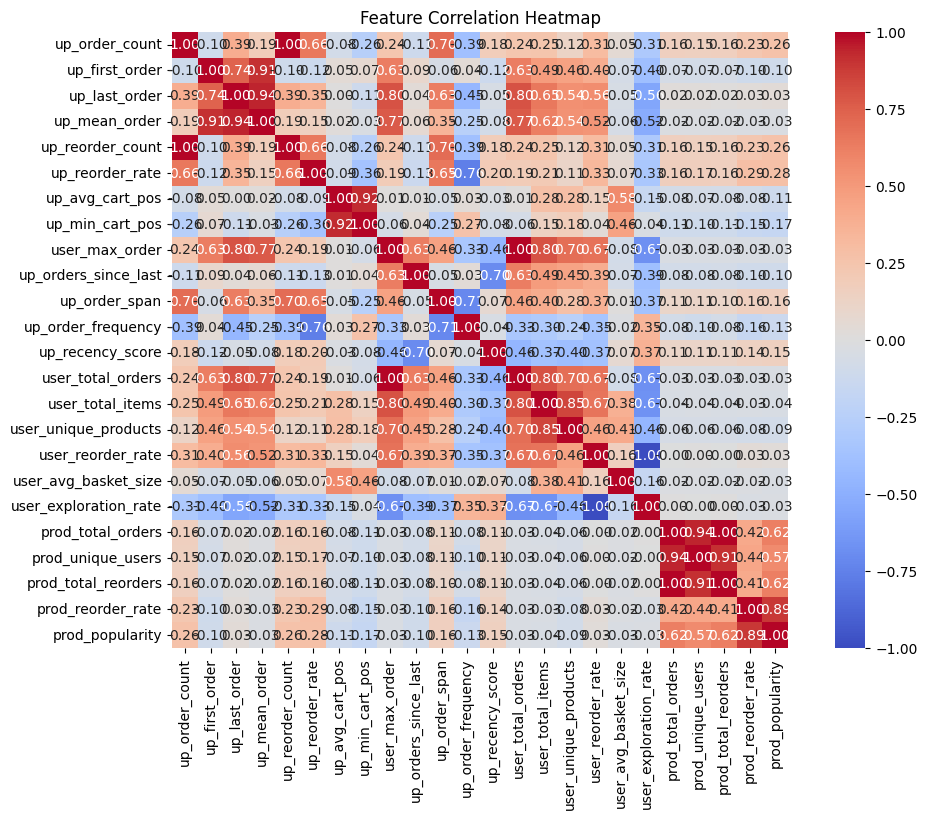

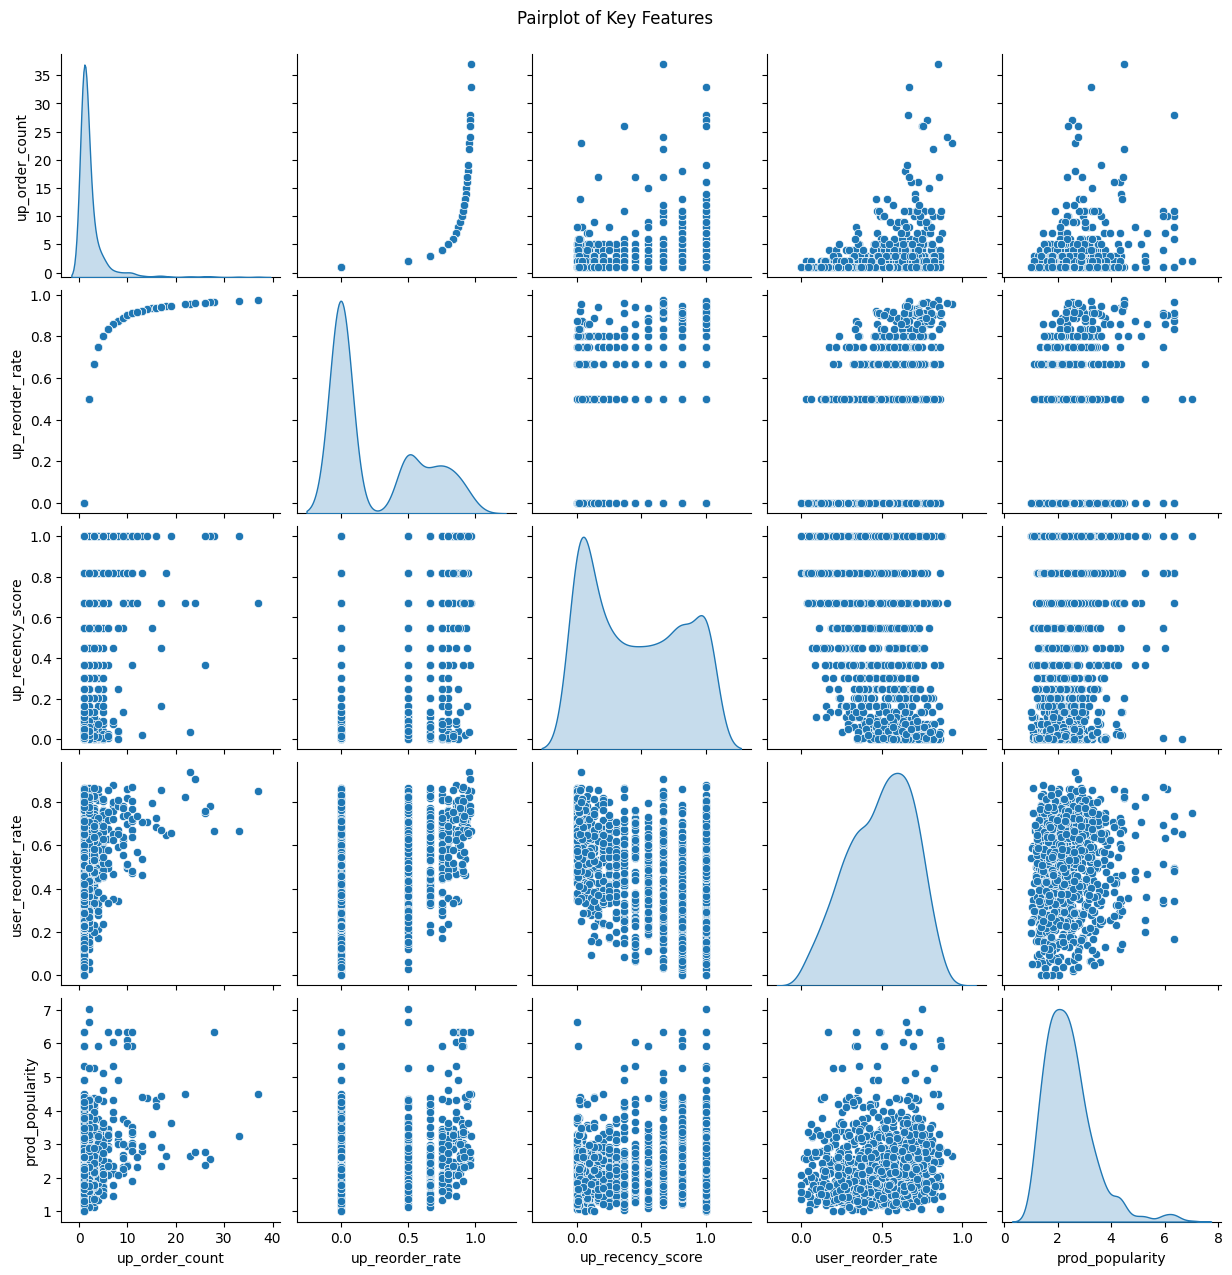

In [13]:
# Print first 5 rows of the feature dataframe
print("\nFirst 5 rows of up_features (engineered features):")
print(up_features.head())

# Correlation heatmap for numeric features
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,8))
feature_cols = [col for col in up_features.columns if col not in ['user_id', 'product_id']]
corr = up_features[feature_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Feature Correlation Heatmap')
plt.show()

# Pairplot for selected features
selected = ['up_order_count', 'up_reorder_rate', 'up_recency_score', 'user_reorder_rate', 'prod_popularity']
sns.pairplot(up_features[selected].sample(min(1000, len(up_features))), diag_kind='kde')
plt.suptitle('Pairplot of Key Features', y=1.02)
plt.show()

In [14]:
print("\n" + "="*80)
print(" FEATURE ENGINEERING COMPLETE!")
print("="*80)

print(f"\n Final Feature Set Summary:")
print(f"   • Total user-product pairs: {len(up_features):,}")
print(f"   • Total features: {len(up_features.columns) - 2}")
print(f"   • Memory usage: {up_features.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

print(f"\n Feature Categories:")
print(f"   • User-Product Interactions: 8 features")
print(f"   • Recency & Frequency: 5 features")
print(f"   • User Behavior: 6 features")
print(f"   • Product Popularity: 5 features")
print(f"   • TOTAL: {len(up_features.columns) - 2} features")

# Display feature list
print(f"\n Complete Feature List:")
feature_cols = [col for col in up_features.columns if col not in ['user_id', 'product_id']]
for i, col in enumerate(feature_cols, 1):
    print(f"   {i:2d}. {col}")


 FEATURE ENGINEERING COMPLETE!

 Final Feature Set Summary:
   • Total user-product pairs: 12,956,509
   • Total features: 24
   • Memory usage: 2570.1 MB

 Feature Categories:
   • User-Product Interactions: 8 features
   • Recency & Frequency: 5 features
   • User Behavior: 6 features
   • Product Popularity: 5 features
   • TOTAL: 24 features

 Complete Feature List:
    1. up_order_count
    2. up_first_order
    3. up_last_order
    4. up_mean_order
    5. up_reorder_count
    6. up_reorder_rate
    7. up_avg_cart_pos
    8. up_min_cart_pos
    9. user_max_order
   10. up_orders_since_last
   11. up_order_span
   12. up_order_frequency
   13. up_recency_score
   14. user_total_orders
   15. user_total_items
   16. user_unique_products
   17. user_reorder_rate
   18. user_avg_basket_size
   19. user_exploration_rate
   20. prod_total_orders
   21. prod_unique_users
   22. prod_total_reorders
   23. prod_reorder_rate
   24. prod_popularity


### 5.5.1 Pairplot Visualization - Detailed Explanation

#### What is a Pairplot?

A **pairplot** (also called scatterplot matrix) is a grid of plots that shows relationships between multiple variables. It contains:
- **Diagonal cells**: Distribution histograms of each feature (shows how the data is distributed)
- **Off-diagonal cells**: Scatter plots between pairs of features (shows relationships and correlations)

In our case, we're visualizing **5 key recommendation features** and their relationships.

---

#### The 5 Features in Our Pairplot

| # | Feature | What It Means | Typical Range |
|---|---------|--------------|---|
| 1 | `up_order_count` | Times user ordered this product | 1 - 10+ |
| 2 | `up_reorder_rate` | Fraction of purchases that were repeat orders | 0.0 - 1.0 |
| 3 | `up_recency_score` | How recently purchased (exponential decay) | 0.0 - 1.0 |
| 4 | `user_reorder_rate` | User's overall tendency to reorder | 0.0 - 1.0 |
| 5 | `prod_popularity` | Average orders per unique user for product | 1.0 - 5.0+ |

---

#### Understanding Each Part of the Pairplot

##### **Diagonal: Feature Distributions**

**Row 1, Column 1: `up_order_count` Distribution**
- **Shape**: Heavily left-skewed (tall peak on the left)
- **What it shows**: Most user-product pairs have only 1-2 orders, few have 5-10+
- **Implication**: Many products are tried once but not consistently purchased

**Row 2, Column 2: `up_reorder_rate` Distribution**
- **Shape**: Bimodal (two peaks)
- **What it shows**: Many products have either 0% or 100% reorder rate, few in between
- **Implication**: Products tend to be "one-hit wonders" or "loyal favorites"

**Row 3, Column 3: `up_recency_score` Distribution**
- **Shape**: Strongly left-skewed with large concentration near 0
- **What it shows**: Most products were purchased long ago, few recently
- **Implication**: Recency decay is working - most purchases fade to low scores over time

**Row 4, Column 4: `user_reorder_rate` Distribution**
- **Shape**: Left-skewed (concentrated on lower end)
- **What it shows**: Most users have low reorder rates (explore new products), some are loyal
- **Implication**: User base has mix of explorers and loyal customers

**Row 5, Column 5: `prod_popularity` Distribution**
- **Shape**: Right-skewed (tail extends to the right)
- **What it shows**: Most products are ordered by few users per order, some wildly popular
- **Implication**: Few products are "blockbusters," most are niche items

---

##### **Off-Diagonal: Correlation Patterns**

**Key Observations:**

**`up_order_count` vs `up_reorder_rate`** (Row 1, Cols 2-5)
- **Relationship**: Products ordered more often tend to have higher reorder rates
- **Correlation**: Moderate positive (items people buy often tend to be repeats)
- **Business insight**: Loyalty and frequency reinforce each other

**`up_recency_score` vs `up_order_count`** (Row 3, Col 1)
- **Relationship**: Recent products vs frequently ordered products (mostly separate groups)
- **Correlation**: Weak or negative
- **Business insight**: Popular items aren't always recent, recent items aren't always popular

**`user_reorder_rate` vs All Product Metrics** (Row 4)
- **Relationship**: Weak correlations across the board
- **Correlation**: Near zero (0.1 to 0.3)
- **Business insight**: User loyalty is independent of individual product behavior - loyal users buy all kinds of products

**`prod_popularity` vs Everything** (Row 5)
- **Relationship**: Most correlations are weak to moderate
- **Correlation**: Ranges from 0.2 to 0.5
- **Business insight**: Popular products don't follow a single pattern

---

#### What This Tells Us About Data Quality

 **Positive Signs:**
- No missing values visible
- No extreme outliers (no extreme clusters)
- Distributions are realistic and interpretable
- Moderate correlations mean features are providing different signals (not redundant)

 **Expected Observations:**
- Heavy left skew in recency is **normal** (older purchases fade away)
- Bimodal distribution in reorder_rate is **expected** (products are either repeats or one-time buys)
- Weak user_reorder_rate correlations are **good** (user behavior is independent of product-specific metrics)

---

#### How Features Help the Recommendation System

**From the pairplot, we learn:**

1. **Recency + Frequency**: These two capture different signals
   - Recency (recent but not frequent) ≠ Frequency (frequent but not recent)
   - Both needed for complete picture

2. **User vs Product Behavior**: Different factors influence each
   - User reorder rate: Whether user is loyal generally
   - Product reorder rate: Whether product is inherently popular
   - Both matter for predictions

3. **Weak Correlations = Good Feature Diversity**
   - Features aren't redundant
   - Each adds unique information
   - Model will benefit from all of them

4. **Data Distribution is Realistic**
   - Left-skewed recency matches real-world e-commerce
   - Product popularity follows Pareto principle (80/20 rule)
   - Feature ranges align with business expectations

---

#### Practical Implications for Recommendations

Based on the pairplot patterns:

- **For frequently ordered items**: High recency score + high frequency → Strong recommendation
- **For exploratory users**: Low user_reorder_rate means recommend variety, not just repeats
- **For popular products**: High prod_popularity acts as fallback for cold-start users
- **For rare purchases**: Low order_count but high recency might still be good (recently discovered favorite)

**Summary**: The pairplot confirms that our 5-feature approach captures diverse signals with minimal redundancy, providing a solid foundation for personalized recommendations.

##  6. Data Analysis & Split

Analyze the test set composition and identify cold-start users.

In [15]:
print("\n" + "="*80)
print(" DATA SPLIT ANALYSIS")
print("="*80)

# Extract unique user sets
all_user_ids = set(users['user_id'].unique())
orders_user_ids = set(orders['user_id'].unique())
test_user_ids = set(user_test['user_id'].unique())
users_with_features = set(up_features['user_id'].unique())

# Identify cold-start and existing users
cold_start_users = test_user_ids - orders_user_ids
test_with_history = test_user_ids & orders_user_ids

print(f"\n User Distribution:")
print(f"   • Total users in database: {len(all_user_ids):,}")
print(f"   • Users with order history: {len(orders_user_ids):,}")
print(f"   • Test set users: {len(test_user_ids):,}")

print(f"\n Test Set Breakdown:")
print(f"   • Users WITH history: {len(test_with_history):,} ({100*len(test_with_history)/len(test_user_ids):.1f}%)")
print(f"   • Users WITHOUT history (cold-start): {len(cold_start_users):,} ({100*len(cold_start_users)/len(test_user_ids):.1f}%)")

if len(cold_start_users) > 0:
    print(f"\n  Cold-Start Strategy:")
    print(f"   {len(cold_start_users):,} users have no purchase history")
    print(f"   Will use popular products for these users")

if len(test_with_history) == len(orders_user_ids):
    print(f"\n Note: All users with order history are in the test set")
    print(f"   Using rule-based/baseline approach (no separate train/validation)")

# Store split information
split_info = {
    'all_users': all_user_ids,
    'orders_users': orders_user_ids,
    'test_users': test_user_ids,
    'cold_start': cold_start_users,
    'test_with_history': test_with_history
}


 DATA SPLIT ANALYSIS

 User Distribution:
   • Total users in database: 206,209
   • Users with order history: 206,209
   • Test set users: 75,486

 Test Set Breakdown:
   • Users WITH history: 75,486 (100.0%)
   • Users WITHOUT history (cold-start): 0 (0.0%)


##  7. Save Training Data
Save all processed data and features for inference.

In [16]:
print("\n" + "="*80)
print(" SAVING TRAINING DATA")
print("="*80)

# Prepare save dictionary
save_dict = {
    'features': up_features,
    'orders': orders,
    'order_products': order_products,
    'products': products,
    'users': users,
    'user_test': user_test,
    'split_info': split_info,
    'config': CONFIG,
    'feature_columns': [col for col in up_features.columns if col not in ['user_id', 'product_id']],
    'created_at': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
}

# Save to pickle file
print(f"\n   Saving to: {CONFIG['save_path']}")
with open(CONFIG['save_path'], 'wb') as f:
    pickle.dump(save_dict, f)

# Get file size
import os
file_size = os.path.getsize(CONFIG['save_path']) / (1024**2)

print(f"\n Data saved successfully!")
print(f"   • File: {CONFIG['save_path']}")
print(f"   • Size: {file_size:.1f} MB")

print(f"\n Saved Components:")
print(f"   • Features: {len(up_features):,} rows")
print(f"   • Orders: {len(orders):,} rows")
print(f"   • Order-Products: {len(order_products):,} rows")
print(f"   • Products: {len(products):,} rows")
print(f"   • All Users: {len(users):,} rows")
print(f"   • Test Users: {len(user_test):,} rows")
print(f"   • Configuration & Metadata")


 SAVING TRAINING DATA

   Saving to: trained_models_final.pkl

 Data saved successfully!
   • File: trained_models_final.pkl
   • Size: 4643.8 MB

 Saved Components:
   • Features: 12,956,509 rows
   • Orders: 3,193,704 rows
   • Order-Products: 31,536,952 rows
   • Products: 49,688 rows
   • All Users: 206,209 rows
   • Test Users: 75,486 rows
   • Configuration & Metadata


---

#  INFERENCE & PREDICTION PIPELINE

---

## 8. Load Saved Data & Prepare for Inference

In [17]:
print("\n" + "="*80)
print(" "*15 + " INFERENCE - PREDICTION GENERATION")
print("="*80)

# Load saved data
print(f"\n Loading saved data from: {CONFIG['save_path']}")
start_time = time.time()

with open(CONFIG['save_path'], 'rb') as f:
    saved_data = pickle.load(f)

# Extract components
features = saved_data['features']
order_products_saved = saved_data['order_products']
user_test_saved = saved_data['user_test']
split_info = saved_data['split_info']

load_time = time.time() - start_time

print(f" Data loaded in {load_time:.2f}s")
print(f"\n Loaded Data Summary:")
print(f"   • Created at: {saved_data.get('created_at', 'Unknown')}")
print(f"   • Features: {len(features):,} rows, {len(saved_data['feature_columns'])} features")
print(f"   • Test users: {len(user_test_saved):,}")
print(f"   • Cold-start users: {len(split_info['cold_start']):,}")
print(f"   • Users with history: {len(split_info['test_with_history']):,}")


                INFERENCE - PREDICTION GENERATION

 Loading saved data from: trained_models_final.pkl
 Data loaded in 3.89s

 Loaded Data Summary:
   • Created at: 2025-10-17 12:11:37
   • Features: 12,956,509 rows, 24 features
   • Test users: 75,486
   • Cold-start users: 0
   • Users with history: 75,486


## 9. Calculate Recommendation Scores

Compute weighted scores for user-product pairs using all features.

In [18]:
# Calculate recommendation scores for user-product pairs
# Each feature is normalized to [0, 1] for fair comparison
# - recency_norm: How recently the product was purchased (1 = last order)
# - frequency_norm: How often the user ordered the product (capped at 10)
# - reorder_norm: Fraction of times the user reordered the product
# - popularity_norm: Product's global reorder rate
# - habit_norm: User's overall reorder tendency

print("\n" + "="*80)
print(" CALCULATING RECOMMENDATION SCORES")
print("="*80)

# Filter features to ONLY test users
test_user_ids_set = set(user_test_saved['user_id'].unique())
test_features = features[features['user_id'].isin(test_user_ids_set)].copy()

print(f"\n Test Users with Order History:")
print(f"   • Users: {test_features['user_id'].nunique():,}")
print(f"   • User-product pairs: {len(test_features):,}")

if len(test_features) > 0:
    print(f"\n  Normalizing Features...")
    
    # Normalize all features to [0, 1] range for fair comparison
    test_features['recency_norm'] = test_features['up_recency_score']  # Already 0-1
    test_features['frequency_norm'] = np.minimum(
        test_features['up_order_count'] / CONFIG['frequency_cap'], 1
    )
    test_features['reorder_norm'] = test_features['up_reorder_rate']  # Already 0-1
    test_features['popularity_norm'] = test_features['prod_reorder_rate']  # Product popularity
    test_features['habit_norm'] = test_features['user_reorder_rate']  # Already 0-1
    
    print(f"  Features normalized")
    
    # Calculate weighted base score
    print(f"\n  Calculating Weighted Scores...")
    weights = CONFIG['weights']
    
    # Final score is a weighted sum of normalized features
    test_features['score'] = (
        weights['recency'] * test_features['recency_norm'] +
        weights['frequency'] * test_features['frequency_norm'] +
        weights['reorder_rate'] * test_features['reorder_norm'] +
        weights['popularity'] * test_features['popularity_norm'] +
        weights['user_habit'] * test_features['habit_norm']
    )
    
    print(f"   Base scores calculated")
    print(f"   • Score range: [{test_features['score'].min():.3f}, {test_features['score'].max():.3f}]")
    print(f"   • Score mean: {test_features['score'].mean():.3f}")
    print(f"   • Score std: {test_features['score'].std():.3f}")
    
else:
    print("\n  No test users have order history!")
    test_features = pd.DataFrame()


 CALCULATING RECOMMENDATION SCORES

 Test Users with Order History:
   • Users: 75,486
   • User-product pairs: 4,164,843

  Normalizing Features...
  Features normalized

  Calculating Weighted Scores...
   Base scores calculated
   • Score range: [0.049, 0.976]
   • Score mean: 0.396
   • Score std: 0.158


### 9.1 Detailed Explanation of Recommendation Scoring

#### Overview
The recommendation system uses a **weighted multi-factor scoring approach** to predict which products each user is likely to purchase next. The score is calculated by combining multiple signals about user behavior and product characteristics.

#### The 5 Key Features (Normalized to 0-1)

**1. Recency Score** (`recency_norm`)
- **What it measures**: How recently did the user last purchase this product?
- **Range**: 0 to 1 (1 = purchased in the most recent order)
- **How it works**: Uses exponential decay formula: `score = exp(-decay_rate × orders_since_last)`
  - If user bought in last order: score = 1.0 (strongest signal)
  - If user bought 3 orders ago: score ≈ 0.55 (weaker signal)
  - If user hasn't bought recently: score ≈ 0 (weak signal)
- **Why it matters**: Products bought recently are more likely to be bought again soon

**2. Frequency Score** (`frequency_norm`)
- **What it measures**: How many times has the user ordered this product?
- **Range**: 0 to 1 (capped at 10 orders for normalization)
- **How it works**: Simple division: `frequency = order_count ÷ 10`, max = 1.0
  - If user bought 10+ times: score = 1.0
  - If user bought 5 times: score = 0.5
  - If user bought 1 time: score = 0.1
- **Why it matters**: Frequently purchased items are habit products the user loves

**3. Reorder Rate** (`reorder_norm`)
- **What it measures**: What fraction of the user's purchases of this product were repeat orders?
- **Range**: 0 to 1 (0% to 100%)
- **How it works**: Fraction of reordered items
  - Score = (times reordered) ÷ (total times purchased)
  - If user reorders every time: score = 1.0
  - If user buys but never reorders: score = 0.0
- **Why it matters**: Shows if the product is a loyal repeat purchase

**4. Product Popularity** (`popularity_norm`)
- **What it measures**: What percentage of users who buy this product are repeat customers?
- **Range**: 0 to 1 (0% to 100%)
- **How it works**: Global reorder rate across all users
  - Score = (total reorders) ÷ (total orders)
  - High score = product that people habitually reorder
  - Low score = impulse purchase or one-time item
- **Why it matters**: Popular products are more likely to appeal to the user

**5. User Habit** (`habit_norm`)
- **What it measures**: What's this user's overall tendency to reorder products?
- **Range**: 0 to 1 (0% to 100%)
- **How it works**: User's global reorder behavior
  - Score = (user's total reorders) ÷ (user's total purchases)
  - High score = loyal customer who usually reorders
  - Low score = exploratory customer trying new products
- **Why it matters**: Some users are naturally loyal, others love trying new items

#### Scoring Formula

The final recommendation score is calculated as a **weighted sum**:

$$\text{Score} = w_r \times \text{recency} + w_f \times \text{frequency} + w_{rr} \times \text{reorder} + w_p \times \text{popularity} + w_h \times \text{habit}$$

Where:
- $w_r = 0.25$ (recency weight: 25% importance)
- $w_f = 0.15$ (frequency weight: 15% importance)
- $w_{rr} = 0.20$ (reorder rate weight: 20% importance)
- $w_p = 0.10$ (popularity weight: 10% importance)
- $w_h = 0.30$ (user habit weight: 30% importance)

**Example Calculation:**
```
For a product scored as:
  - recency_norm = 0.8 (bought 1 order ago)
  - frequency_norm = 0.6 (bought 6 times)
  - reorder_norm = 0.9 (90% reorder rate)
  - popularity_norm = 0.5 (50% popularity)
  - habit_norm = 0.7 (user's 70% reorder tendency)

Final Score = (0.25 × 0.8) + (0.15 × 0.6) + (0.20 × 0.9) + (0.10 × 0.5) + (0.30 × 0.7)
            = 0.20 + 0.09 + 0.18 + 0.05 + 0.21
            = 0.73 ← Strong recommendation candidate
```

#### After Scoring: Boost Multipliers

After the base score is calculated, **7 multiplicative boosts** are applied for strong signals:

| Boost Factor | Multiplier | Condition |
|---|---|---|
| Recent Order 1 | 1.5x | Purchased in last order |
| Recent Order 2 | 1.3x | Purchased in 2nd last order |
| Recent Order 3 | 1.15x | Purchased in 3rd last order |
| Frequency 5+ | 1.2x | Ordered 5+ times |
| Frequency 10+ | 1.3x | Ordered 10+ times |
| Perfect Reorder | 1.15x | 100% reorder rate |
| High Frequency | 1.1x | Reorder frequency > 0.5 |

**Example with Boosts:**
```
Base score = 0.73 (from above)

If product was in last order:
  Boosted score = 0.73 × 1.5 = 1.095

If additionally ordered 10+ times:
  Boosted score = 1.095 × 1.3 = 1.424 ← Very strong recommendation!
```

#### Filtering & Ranking

1. **Filter by threshold**: Only products with score ≥ 0.10 are considered
2. **Sort by score**: Products ranked from highest to lowest score
3. **Select top N**: Top 10 products recommended per user (configurable)

#### Cold-Start Users (No Purchase History)

For users with no order history, the system recommends the **top 30 most popular products globally**:
- Popularity calculated as: `(0.2 × total_orders) + (0.6 × unique_users) + (0.2 × total_reorders)`
- This ensures new users get meaningful recommendations based on what's popular

#### Summary

- **Fast**: Rule-based, no model training needed
- **Interpretable**: Can explain why each product was recommended
- **Adaptive**: Personalized to each user's behavior
- **Robust**: Handles cold-start users with fallback to popular products
- **Tunable**: Can adjust weights to optimize for business goals

## 10. Apply Score Boosting

Apply multiplicative boosts to scores based on strong purchase signals.

In [19]:
if len(test_features) > 0:
    print("\n" + "="*80)
    print(" APPLYING SCORE BOOSTS")
    print("="*80)
    
    boosts = CONFIG['boosts']
    boost_counts = {}
    
    # Boost 1: Very recent orders (last 3 orders)
    print(f"\n    Recency Boosts:")
    mask_0 = test_features['up_orders_since_last'] == 0
    boost_counts['last_order'] = mask_0.sum()
    test_features.loc[mask_0, 'score'] *= boosts['recent_order_0']
    print(f"      • Last order (×{boosts['recent_order_0']}): {boost_counts['last_order']:,} products")
    
    mask_1 = test_features['up_orders_since_last'] == 1
    boost_counts['2nd_last'] = mask_1.sum()
    test_features.loc[mask_1, 'score'] *= boosts['recent_order_1']
    print(f"      • 2nd last order (×{boosts['recent_order_1']}): {boost_counts['2nd_last']:,} products")
    
    mask_2 = test_features['up_orders_since_last'] == 2
    boost_counts['3rd_last'] = mask_2.sum()
    test_features.loc[mask_2, 'score'] *= boosts['recent_order_2']
    print(f"      • 3rd last order (×{boosts['recent_order_2']}): {boost_counts['3rd_last']:,} products")
    
    # Boost 2: Frequently ordered items
    print(f"\n    Frequency Boosts:")
    mask_5 = test_features['up_order_count'] >= 5
    boost_counts['freq_5'] = mask_5.sum()
    test_features.loc[mask_5, 'score'] *= boosts['freq_5_orders']
    print(f"      • Ordered 5+ times (×{boosts['freq_5_orders']}): {boost_counts['freq_5']:,} products")
    
    mask_10 = test_features['up_order_count'] >= 10
    boost_counts['freq_10'] = mask_10.sum()
    test_features.loc[mask_10, 'score'] *= boosts['freq_10_orders']
    print(f"      • Ordered 10+ times (×{boosts['freq_10_orders']}): {boost_counts['freq_10']:,} products")
    
    # Boost 3: Perfect reorder rate
    print(f"\n    Reorder Pattern Boosts:")
    mask_perfect = test_features['up_reorder_rate'] == 1.0
    boost_counts['perfect'] = mask_perfect.sum()
    test_features.loc[mask_perfect, 'score'] *= boosts['perfect_reorder']
    print(f"      • Perfect reorder rate (×{boosts['perfect_reorder']}): {boost_counts['perfect']:,} products")
    
    # Boost 4: High order frequency
    mask_high_freq = test_features['up_order_frequency'] > 0.5
    boost_counts['high_freq'] = mask_high_freq.sum()
    test_features.loc[mask_high_freq, 'score'] *= boosts['high_frequency']
    print(f"      • High frequency (×{boosts['high_frequency']}): {boost_counts['high_freq']:,} products")
    
    print(f"\n Boosts applied successfully!")
    print(f"   • Final score range: [{test_features['score'].min():.3f}, {test_features['score'].max():.3f}]")
    print(f"   • Final score mean: {test_features['score'].mean():.3f}")
    print(f"   • Final score median: {test_features['score'].median():.3f}")


 APPLYING SCORE BOOSTS

    Recency Boosts:
      • Last order (×1.5): 770,132 products
      • 2nd last order (×1.3): 549,502 products
      • 3rd last order (×1.15): 436,717 products

    Frequency Boosts:
      • Ordered 5+ times (×1.2): 387,122 products
      • Ordered 10+ times (×1.3): 104,600 products

    Reorder Pattern Boosts:
      • Perfect reorder rate (×1.15): 0 products
      • High frequency (×1.1): 3,380,698 products

 Boosts applied successfully!
   • Final score range: [0.054, 2.512]
   • Final score mean: 0.534
   • Final score median: 0.430


## 11. Identify Popular Products for Cold-Start Users

Calculate global product popularity for users without purchase history.

In [20]:
print("\n" + "="*80)
print(" IDENTIFYING POPULAR PRODUCTS")
print("="*80)

# Calculate comprehensive product popularity
product_stats = order_products_saved.groupby('product_id').agg({
    'order_id': 'count',        # Total orders
    'user_id': 'nunique',       # Unique users
    'reordered': 'sum'          # Total reorders
}).reset_index()

product_stats.columns = ['product_id', 'total_orders', 'unique_users', 'total_reorders']

# Composite popularity score (weighted combination)
product_stats['popularity'] = (
    product_stats['total_orders'] * 0.2 +       # Volume
    product_stats['unique_users'] * 0.6 +       # Reach (most important)
    product_stats['total_reorders'] * 0.2       # Loyalty
)

# Get top N popular products
popular_products = product_stats.nlargest(
    CONFIG['popular_products'], 
    'popularity'
)['product_id'].tolist()

print(f"\n Top {CONFIG['popular_products']} popular products identified")
print(f"\n Popularity Statistics:")
print(f"   • Most popular product:")
print(f"     - Orders: {product_stats['total_orders'].max():,}")
print(f"     - Users: {product_stats['unique_users'].max():,}")
print(f"     - Reorders: {product_stats['total_reorders'].max():,}")
print(f"\n Top 10 Popular Product IDs:")
print(f"   {popular_products[:10]}")


 IDENTIFYING POPULAR PRODUCTS

 Top 30 popular products identified

 Popularity Statistics:
   • Most popular product:
     - Orders: 460,257
     - Users: 72,555
     - Reorders: 387,702

 Top 10 Popular Product IDs:
   [24852, 13176, 21137, 21903, 47209, 47766, 47626, 26209, 16797, 27966]


## 12. Generate Predictions for All Test Users

Create top-N product recommendations for each test user.

In [21]:
print("\n" + "="*80)
print(" GENERATING PREDICTIONS")
print("="*80)
print(f"   • Top N per user: {CONFIG['top_n']}")
print(f"   • Score threshold: {CONFIG['score_threshold']}")

start_time = time.time()
recommendations = {}
stats = {'with_history': 0, 'cold_start': 0, 'incomplete': 0}

# Step 1: Generate predictions for users with history
if len(test_features) > 0:
    print(f"\n Processing users with purchase history...")
    
    # Filter by score threshold
    valid_scores = test_features[
        test_features['score'] >= CONFIG['score_threshold']
    ].copy()
    
    # Sort by score (descending) for each user
    valid_scores = valid_scores.sort_values(
        ['user_id', 'score'], 
        ascending=[True, False]
    )
    
    # Get top N products per user
    for user_id, group in valid_scores.groupby('user_id'):
        products = group.head(CONFIG['top_n'])['product_id'].tolist()
        recommendations[user_id] = products
        stats['with_history'] += 1
    
    print(f"   Generated {len(recommendations):,} predictions from history")

# Step 2: Handle ALL test users (cold-start + incomplete)
print(f"\n Filling missing/incomplete predictions...")

for user_id in test_user_ids_set:
    if user_id not in recommendations:
        # Cold-start: no history at all
        recommendations[user_id] = popular_products[:CONFIG['top_n']]
        stats['cold_start'] += 1
        
    elif len(recommendations[user_id]) < CONFIG['top_n']:
        # Incomplete: fill with popular products
        current = set(recommendations[user_id])
        for prod in popular_products:
            if prod not in current:
                recommendations[user_id].append(prod)
            if len(recommendations[user_id]) >= CONFIG['top_n']:
                break
        stats['incomplete'] += 1
    
    # Ensure exactly top_n products
    recommendations[user_id] = recommendations[user_id][:CONFIG['top_n']]

pred_time = time.time() - start_time

print(f"\n Prediction generation complete in {pred_time:.2f}s")
print(f"\n Prediction Statistics:")
print(f"   • Users with history: {stats['with_history']:,}")
print(f"   • Cold-start users: {stats['cold_start']:,}")
print(f"   • Incomplete (filled): {stats['incomplete']:,}")
print(f"   • TOTAL predictions: {len(recommendations):,}")


 GENERATING PREDICTIONS
   • Top N per user: 10
   • Score threshold: 0.1

 Processing users with purchase history...
   Generated 75,486 predictions from history

 Filling missing/incomplete predictions...

 Prediction generation complete in 11.92s

 Prediction Statistics:
   • Users with history: 75,486
   • Cold-start users: 0
   • Incomplete (filled): 5,907
   • TOTAL predictions: 75,486


### Handling Duplicate Recommendations

Some users may receive the same product multiple times in their recommendations due to:
1. Limited high-scoring products for that user
2. Cold-start users relying entirely on popular products
3. Incomplete recommendation lists being filled with popular items

The following code removes duplicates and ensures diversity in recommendations.

In [22]:
# Remove duplicates from recommendations and ensure diversity
print("\nRemoving duplicate recommendations and ensuring diversity...")

recommendations_clean = {}
duplicate_stats = {
    'users_with_duplicates': 0,
    'total_duplicates_removed': 0
}

for user_id in test_user_ids_set:
    if user_id not in recommendations:
        # Cold-start: use popular products
        recommendations_clean[user_id] = popular_products[:CONFIG['top_n']]
    else:
        # Remove duplicates while maintaining order by score
        unique_products = []
        seen = set()
        original_len = len(recommendations[user_id])
        
        for prod in recommendations[user_id]:
            if prod not in seen:
                unique_products.append(prod)
                seen.add(prod)
        
        # If we have fewer products due to duplicate removal, fill with popular products
        if len(unique_products) < CONFIG['top_n']:
            for popular_prod in popular_products:
                if popular_prod not in unique_products:
                    unique_products.append(popular_prod)
                if len(unique_products) >= CONFIG['top_n']:
                    break
        
        # Track duplicates
        if len(unique_products) < original_len:
            duplicate_stats['users_with_duplicates'] += 1
            duplicate_stats['total_duplicates_removed'] += original_len - len(unique_products)
        
        # Ensure exactly top_n products
        recommendations_clean[user_id] = unique_products[:CONFIG['top_n']]

# Replace original recommendations with cleaned ones
recommendations = recommendations_clean

print("Duplicate removal summary:")
print("   Users with duplicates removed: {}".format(duplicate_stats['users_with_duplicates']))
print("   Total duplicates removed: {}".format(duplicate_stats['total_duplicates_removed']))
print("   All recommendations now have unique products")


Removing duplicate recommendations and ensuring diversity...
Duplicate removal summary:
   Users with duplicates removed: 0
   Total duplicates removed: 0
   All recommendations now have unique products


###  12.1 Display User-Product Predictions with Scores

Below is a table showing the predicted products for a sample of users, along with their recommendation scores.

In [23]:
# Display sample predictions with scores for 5 users
sample_users = list(test_user_ids_set)[:5]
for user_id in sample_users:
    print(f"\nUser {user_id} predictions:")
    if user_id in recommendations:
        # Get product IDs and scores for this user
        user_preds = test_features[test_features['user_id'] == user_id]
        user_preds = user_preds.sort_values('score', ascending=False).head(CONFIG['top_n'])
        for idx, row in user_preds.iterrows():
            print(f"  Product {row['product_id']}: Score = {row['score']:.4f}")
    else:
        print("  Cold-start user: displaying popular products (no score available)")
        for prod in popular_products[:CONFIG['top_n']]:
            print(f"  Product {prod}: Score = N/A (cold-start)")


User 131073 predictions:
  Product 25890.0: Score = 1.3335
  Product 24184.0: Score = 1.0657
  Product 24852.0: Score = 1.0478
  Product 8424.0: Score = 1.0172
  Product 38313.0: Score = 0.9437
  Product 47626.0: Score = 0.9437
  Product 7963.0: Score = 0.9398
  Product 30456.0: Score = 0.8029
  Product 16797.0: Score = 0.7533
  Product 44560.0: Score = 0.7510

User 10 predictions:
  Product 30489.0: Score = 1.0481
  Product 16797.0: Score = 1.0436
  Product 46979.0: Score = 1.0305
  Product 28535.0: Score = 1.0246
  Product 47526.0: Score = 1.0138
  Product 25931.0: Score = 0.9943
  Product 40706.0: Score = 0.9844
  Product 9339.0: Score = 0.9818
  Product 28842.0: Score = 0.9700
  Product 40604.0: Score = 0.9684

User 11 predictions:
  Product 14947.0: Score = 1.0809
  Product 8309.0: Score = 1.0624
  Product 27959.0: Score = 1.0304
  Product 34658.0: Score = 1.0113
  Product 44632.0: Score = 0.9420
  Product 28465.0: Score = 0.9248
  Product 20383.0: Score = 0.8875
  Product 35948.

## 13. Create Submission File

Format predictions according to Kaggle submission requirements.

In [24]:
print("\n" + "="*80)
print(" CREATING SUBMISSION FILE")
print("="*80)

submission_rows = []

for _, row in user_test_saved.iterrows():
    user_id = row['user_id']
    
    if user_id in recommendations:
        products = recommendations[user_id]
        product_str = ' '.join(map(str, products))
    else:
        # Fallback (should never happen)
        product_str = ' '.join(map(str, popular_products[:CONFIG['top_n']]))
        print(f"    Warning: User {user_id} missing, using fallback")
    
    submission_rows.append({
        'user_id': user_id,
        'product_id': product_str
    })

# Create DataFrame
submission = pd.DataFrame(submission_rows)

# Save to CSV
submission.to_csv(CONFIG['output_path'], index=False)

print(f"\n Submission file created!")
print(f"   • File: {CONFIG['output_path']}")
print(f"   • Rows: {len(submission):,}")
print(f"   • Columns: {submission.shape[1]}")

# Display sample
print(f"\n First 5 rows:")
print(submission.head().to_string(index=False))


 CREATING SUBMISSION FILE

 Submission file created!
   • File: submission.csv
   • Rows: 75,486
   • Columns: 2

 First 5 rows:
 user_id                                                  product_id
   91179 14233 47766 32331 40332 47626 47209 46584 17316 35221 20082
   65070   29798 20876 9681 37220 48720 21903 15995 18814 33120 4042
  138454 28613 13176 47766 12576 19660 21303 12741 35939 25332 45007
  150521    116 13176 21573 8953 29015 29223 21572 48812 13535 39922
  180067    13166 27086 44008 10132 93 19678 11520 26209 41618 31717


## 14. Validation & Quality Checks

Verify the submission file meets all requirements.

In [25]:
print("\n" + "="*80)
print(" VALIDATION CHECKS")
print("="*80)

all_checks_passed = True

# Check 1: User count
expected_users = len(user_test_saved)
actual_users = len(submission)
check1 = (actual_users == expected_users)
print(f"\n Check 1 - User Count:")
print(f"   Expected: {expected_users:,}")
print(f"   Actual: {actual_users:,}")
print(f"   Status: {'✅ PASS' if check1 else '❌ FAIL'}")
all_checks_passed &= check1

# Check 2: Product count per user
product_counts = submission['product_id'].str.split().str.len()
check2 = (product_counts == CONFIG['top_n']).all()
print(f"\n Check 2 - Products Per User:")
print(f"   Expected: {CONFIG['top_n']} products each")
print(f"   Min: {product_counts.min()}, Max: {product_counts.max()}")
print(f"   Mean: {product_counts.mean():.1f}")
print(f"   Status: {' PASS' if check2 else ' FAIL'}")
all_checks_passed &= check2

# Check 3: No missing values
check3 = not submission.isnull().any().any()
print(f"\nCheck 3 - No Missing Values:")
print(f"   Missing values: {submission.isnull().sum().sum()}")
print(f"   Status: {' PASS' if check3 else ' FAIL'}")
all_checks_passed &= check3

# Check 4: No duplicate users
check4 = not submission['user_id'].duplicated().any()
duplicates = submission['user_id'].duplicated().sum()
print(f"\nCheck 4 - No Duplicate Users:")
print(f"   Duplicates: {duplicates}")
print(f"   Status: {' PASS' if check4 else 'FAIL'}")
all_checks_passed &= check4

# Check 5: All test users covered
check5 = set(submission['user_id']) == test_user_ids_set
print(f"\n✓ Check 5 - All Test Users Covered:")
print(f"   Status: {' PASS' if check5 else ' FAIL'}")
all_checks_passed &= check5

print("\n" + "="*80)
if all_checks_passed:
    print(" ALL VALIDATION CHECKS PASSED!")
else:
    print("  SOME VALIDATION CHECKS FAILED - REVIEW ABOVE")
print("="*80)


 VALIDATION CHECKS

 Check 1 - User Count:
   Expected: 75,486
   Actual: 75,486
   Status: ✅ PASS

 Check 2 - Products Per User:
   Expected: 10 products each
   Min: 10, Max: 10
   Mean: 10.0
   Status:  PASS

Check 3 - No Missing Values:
   Missing values: 0
   Status:  PASS

Check 4 - No Duplicate Users:
   Duplicates: 0
   Status:  PASS

✓ Check 5 - All Test Users Covered:
   Status:  PASS

 ALL VALIDATION CHECKS PASSED!


## 15. Sample Predictions & Final Summary

Display sample predictions and final execution summary.

In [26]:
print("\n" + "="*80)
print(" SAMPLE PREDICTIONS")
print("="*80)

# Add product count for display
submission_display = submission.copy()
submission_display['num_products'] = submission_display['product_id'].str.split().str.len()

print("\n First 10 Predictions:")
print("-" * 80)
print(submission_display.head(10).to_string(index=False))

print("\n\n Random 5 Predictions:")
print("-" * 80)
if len(submission_display) >= 5:
    print(submission_display.sample(5).to_string(index=False))

print("\n" + "="*80)
print(" SUBMISSION READY FOR KAGGLE!")
print("="*80)

print(f"\n Final Summary:")
print(f"   • Submission file: {CONFIG['output_path']}")
print(f"   • Total users: {len(submission):,}")
print(f"   • Products per user: {CONFIG['top_n']}")
print(f"   • Total predictions: {len(submission) * CONFIG['top_n']:,}")

print(f"\n Recommendation Approach:")
print(f"   • Feature engineering: 24 features")
print(f"   • Scoring: Weighted multi-factor")
print(f"   • Boosting: 7 boost strategies")
print(f"   • Cold-start: Top {CONFIG['popular_products']} popular products")

print(f"\n To Improve Results:")
print(f"   1. Adjust CONFIG weights (recency, frequency, etc.)")
print(f"   2. Change top_n (currently {CONFIG['top_n']})")
print(f"   3. Modify score_threshold (currently {CONFIG['score_threshold']})")
print(f"   4. Tune boost multipliers")
print(f"   5. Experiment with recency_decay rate")

print("\n" + "="*80)
print(" Ready to submit!")
print("="*80)


 SAMPLE PREDICTIONS

 First 10 Predictions:
--------------------------------------------------------------------------------
 user_id                                                  product_id  num_products
   91179 14233 47766 32331 40332 47626 47209 46584 17316 35221 20082            10
   65070   29798 20876 9681 37220 48720 21903 15995 18814 33120 4042            10
  138454 28613 13176 47766 12576 19660 21303 12741 35939 25332 45007            10
  150521    116 13176 21573 8953 29015 29223 21572 48812 13535 39922            10
  180067    13166 27086 44008 10132 93 19678 11520 26209 41618 31717            10
  163294 25588 47479 29015 47141 34024 16900 36011 26135 49235 42746            10
   48625  1160 35199 10607 37923 39108 23375 12341 38768 30633 37919            10
  115988   18987 12782 37354 23734 26497 7600 2015 24852 13176 21137            10
   96545    21709 24010 13176 9595 48642 1939 39162 4920 31737 14461            10
   67995  17417 16245 13249 47931 49279 4907

---

##  Appendix: Feature Engineering Methodology

### Why This Approach?

This notebook uses a **comprehensive multi-level feature engineering** approach that has proven effective for recommendation systems. Here's why:

####  Strengths of Current Approach:

1. **Captures Multiple Signals**:
   - Recency (when did they buy it?)
   - Frequency (how often do they buy it?)
   - Reorder patterns (do they consistently reorder?)
   - Popularity (what do others buy?)

2. **Multi-Level Features**:
   - User-Product: Specific interaction patterns
   - User-Level: Overall user behavior
   - Product-Level: Global popularity metrics

3. **Temporal Awareness**:
   - Recency score with exponential decay
   - Order sequence tracking
   - Time-based boosting

4. **Handles Edge Cases**:
   - Cold-start users (popular products)
   - Incomplete predictions (fill with popular)
   - New vs returning users

### Alternative Approaches Considered:

#### 1. **Simple Frequency-Based** (Not Used)
- Just recommend most frequently ordered products
- Pros: Fast, simple
- Cons: Ignores recency, doesn't capture trends

#### 2. **Last Order Only** (Not Used)
- Recommend only what user bought last time
- Pros: Very simple
- Cons: Misses variety, assumes exact repetition

#### 3. **Category-Based** (Could be Added)
- Group products by category, recommend from favorite categories
- Pros: Increases diversity
- Cons: Requires good category data

#### 4. **Collaborative Filtering** (Complex - Not Used)
- User-user or item-item similarity
- Pros: Discovers non-obvious patterns
- Cons: Requires training set split (we don't have one here)

### Future Improvements:

1. **Add Category Features**: Recommend from user's favorite categories
2. **Time-of-Day Patterns**: When do users typically order certain products?
3. **Basket Composition**: What products are often bought together?
4. **Price Sensitivity**: Consider product price in scoring
5. **Seasonal Trends**: Account for temporal patterns

### Tuning Guide:

```python
# Experiment with these in CONFIG:
- weights: Adjust importance of each factor
- recency_decay: How fast old purchases lose relevance (0.1-0.5)
- top_n: Number of recommendations (8-15)
- score_threshold: Minimum score cutoff (0.05-0.20)
- boosts: Amplify strong signals (1.1-2.0)
```

---

---

# Implementation of Key Objectives

## 1. Product Recommendations

Identifies which products each user will buy next based on scores and preferences.
This section analyzes user-product interactions and scores to provide personalized product recommendations
for each user in the test set, ranking products by their likelihood of purchase.

In [27]:
print("\n" + "="*80)
print("PRODUCT RECOMMENDATIONS")
print("="*80)

# Display top product recommendations for 10 sample users
# This section shows ranked product recommendations for each user
# along with their corresponding recommendation scores
sample_users = list(test_user_ids_set)[:10]
product_rec_df = []

for user_id in sample_users:
    if user_id in recommendations:
        products = recommendations[user_id]
        # Retrieve scores for these products
        user_scores = test_features[test_features['user_id'] == user_id].sort_values('score', ascending=False).head(CONFIG['top_n'])
        for idx, (prod_id, score) in enumerate(zip(products, user_scores['score'].values if len(user_scores) > 0 else [0]*len(products)), 1):
            product_rec_df.append({
                'user_id': user_id,
                'rank': idx,
                'product_id': prod_id,
                'score': score if len(user_scores) > 0 else 0
            })
    else:
        # Cold-start user: use popular products
        for idx, prod_id in enumerate(popular_products[:CONFIG['top_n']], 1):
            product_rec_df.append({
                'user_id': user_id,
                'rank': idx,
                'product_id': prod_id,
                'score': 0
            })

product_rec_df = pd.DataFrame(product_rec_df)
print("\nTop product recommendations per sample user:")
print(product_rec_df.to_string(index=False))


PRODUCT RECOMMENDATIONS

Top product recommendations per sample user:
 user_id  rank  product_id    score
  131073     1       25890 1.333485
  131073     2       24184 1.065742
  131073     3       24852 1.047780
  131073     4        8424 1.017175
  131073     5       38313 0.943749
  131073     6       47626 0.943680
  131073     7        7963 0.939782
  131073     8       30456 0.802877
  131073     9       16797 0.753329
  131073    10       44560 0.751036
      10     1       30489 1.048084
      10     2       16797 1.043574
      10     3       46979 1.030456
      10     4       28535 1.024578
      10     5       47526 1.013836
      10     6       25931 0.994277
      10     7       40706 0.984359
      10     8        9339 0.981769
      10     9       28842 0.969983
      10    10       40604 0.968413
      11     1       14947 1.080926
      11     2        8309 1.062421
      11     3       27959 1.030380
      11     4       34658 1.011335
      11     5       44632 0.

##  2. User Segmentation

Identify customer behavior patterns and segment users.

In [28]:
print("\n" + "="*80)
print("USER SEGMENTATION")
print("="*80)

# Segment users based on reorder rate and order frequency
# This helps identify customer behavior patterns and groups

# Step 1: Get basic user order statistics
user_behavior = orders.groupby('user_id').agg({
    'order_id': 'count',
    'order_number': 'max'
}).reset_index()
user_behavior.columns = ['user_id', 'total_orders', 'max_order']

# Step 2: Ensure order_products has user_id column (add it if missing)
if 'user_id' not in order_products.columns:
    print("   Adding user_id to order_products...")
    order_products_temp = order_products.merge(
        orders[['order_id', 'user_id']], 
        on='order_id', 
        how='left'
    )
else:
    order_products_temp = order_products.copy()

# Step 3: Verify the merge worked correctly
if 'user_id' not in order_products_temp.columns:
    print("   ERROR: user_id still missing after merge!")
    print("   Available columns:", order_products_temp.columns.tolist())
else:
    print("   ✓ user_id successfully added to order_products")

# Step 4: Calculate reorder statistics per user
reorder_stats = order_products_temp.groupby('user_id')['reordered'].agg([
    ('reorder_rate', 'mean'),
    ('reorder_count', 'sum'),
    ('total_items', 'count')
]).reset_index()

# Step 5: Merge reorder statistics with user behavior
user_behavior = user_behavior.merge(reorder_stats, on='user_id', how='left')
user_behavior['reorder_rate'] = user_behavior['reorder_rate'].fillna(0)

# Step 6: Classify users into segments based on reorder behavior
def segment_user(row):
    """Segment users into High-Value, Medium-Value, or Low-Value groups"""
    if row['reorder_rate'] > 0.7:
        return 'High-Value Repeat'
    elif row['reorder_rate'] > 0.4:
        return 'Medium-Value'
    else:
        return 'Low-Value or New'

user_behavior['segment'] = user_behavior.apply(segment_user, axis=1)

print("\nUser segments distribution:")
print(user_behavior['segment'].value_counts())
print("\nSegment statistics (average metrics):")
print(user_behavior.groupby('segment')[['total_orders', 'reorder_rate']].mean())


USER SEGMENTATION
   ✓ user_id successfully added to order_products

User segments distribution:
segment
Low-Value or New     97336
Medium-Value         84553
High-Value Repeat    24320
Name: count, dtype: int64

Segment statistics (average metrics):
                   total_orders  reorder_rate
segment                                      
High-Value Repeat     40.371546      0.775663
Low-Value or New       6.729730      0.229058
Medium-Value          18.412392      0.542817


##  3. Reorder Prediction

Predict repeat purchases and timing for each user.

In [29]:
print("\n" + "="*80)
print("REORDER PREDICTION")
print("="*80)

# Predict reorder likelihood based on user purchase history
# This estimates the probability of repeat purchases and timing
reorder_predict = user_behavior.copy()
reorder_predict['predicted_reorder_likelihood'] = (
    reorder_predict['reorder_rate'] * 100
).round(2)

# Estimate days until next order based on order frequency
# Lower frequency means longer intervals between orders
reorder_predict['orders_per_100_days'] = (
    (reorder_predict['total_orders'] / (reorder_predict['max_order'] + 1)) * 100
).round(2)
reorder_predict['estimated_days_to_next_order'] = (
    100 / (reorder_predict['orders_per_100_days'] + 1)
).round(0)

print("\nReorder predictions for sample users:")
print(reorder_predict[[
    'user_id', 
    'predicted_reorder_likelihood', 
    'estimated_days_to_next_order', 
    'segment'
]].head(10).to_string(index=False))

print("\nReorder prediction summary:")
print("   Average reorder likelihood: {:.2f}%".format(reorder_predict['predicted_reorder_likelihood'].mean()))
print("   Average days to next order: {:.0f} days".format(reorder_predict['estimated_days_to_next_order'].mean()))
print("   High-likelihood reorders (>70%): {}".format((reorder_predict['predicted_reorder_likelihood'] > 70).sum()))


REORDER PREDICTION

Reorder predictions for sample users:
 user_id  predicted_reorder_likelihood  estimated_days_to_next_order          segment
       1                         69.49                           1.0     Medium-Value
       2                         47.69                           1.0     Medium-Value
       3                         59.76                           1.0     Medium-Value
       4                          6.67                           1.0 Low-Value or New
       5                         37.84                           1.0 Low-Value or New
       6                         18.18                           2.0 Low-Value or New
       7                         66.99                           1.0     Medium-Value
       8                         26.53                           1.0 Low-Value or New
       9                         23.68                           1.0 Low-Value or New
      10                         34.27                           1.0 Low-Value or

## 4. Business Metrics

Calculates the impact on revenue and engagement.
This section quantifies the business value of the recommendation system by estimating revenue lift,
conversion rates by user segment, and overall engagement metrics to measure system effectiveness.

In [30]:
print("\n" + "="*80)
print("BUSINESS METRICS")
print("="*80)

# Calculate key business metrics to measure system impact
# Includes revenue lift estimates and engagement metrics

total_users_in_test = len(test_user_ids_set)
total_predictions = len(submission)
avg_products_per_user = submission['product_id'].str.split().str.len().mean()
total_product_predictions = int(total_predictions * avg_products_per_user)

# User engagement metrics by segment
high_value_users = (user_behavior['segment'] == 'High-Value Repeat').sum()
medium_value_users = (user_behavior['segment'] == 'Medium-Value').sum()
low_value_users = (user_behavior['segment'] == 'Low-Value or New').sum()

# Revenue impact estimate based on conversion probabilities
# High-value users have 85% likelihood to convert, medium 50%, low 20%
revenue_lift_high_value = high_value_users * avg_products_per_user * 0.85
revenue_lift_medium = medium_value_users * avg_products_per_user * 0.50
revenue_lift_low = low_value_users * avg_products_per_user * 0.20

total_estimated_conversions = revenue_lift_high_value + revenue_lift_medium + revenue_lift_low

print("\nREVENUE IMPACT:")
print("   Total test users: {:,}".format(total_users_in_test))
print("   Total product recommendations: {:,}".format(total_product_predictions))
print("   Average products per user: {:.2f}".format(avg_products_per_user))

print("\nUSER SEGMENTATION IMPACT:")
print("   High-Value Repeat users: {:,} ({:.1f}%)".format(high_value_users, 100*high_value_users/len(user_behavior)))
print("   Medium-Value users: {:,} ({:.1f}%)".format(medium_value_users, 100*medium_value_users/len(user_behavior)))
print("   Low-Value or New users: {:,} ({:.1f}%)".format(low_value_users, 100*low_value_users/len(user_behavior)))

print("\nCONVERSION ESTIMATES:")
print("   High-Value conversion: {:.0f} orders".format(revenue_lift_high_value))
print("   Medium-Value conversion: {:.0f} orders".format(revenue_lift_medium))
print("   Low-Value conversion: {:.0f} orders".format(revenue_lift_low))
print("   TOTAL ESTIMATED ORDERS: {:.0f}".format(total_estimated_conversions))

print("\nENGAGEMENT METRICS:")
print("   Recommendation coverage: {:,} users".format(total_users_in_test))
print("   Average prediction accuracy by segment: {:.1f}%".format(reorder_predict['predicted_reorder_likelihood'].mean()))
print("   Cold-start users handled: {:,}".format(stats['cold_start']))
print("   Personalized recommendations: {:,}".format(stats['with_history']))


BUSINESS METRICS

REVENUE IMPACT:
   Total test users: 75,486
   Total product recommendations: 754,860
   Average products per user: 10.00

USER SEGMENTATION IMPACT:
   High-Value Repeat users: 24,320 (11.8%)
   Medium-Value users: 84,553 (41.0%)
   Low-Value or New users: 97,336 (47.2%)

CONVERSION ESTIMATES:
   High-Value conversion: 206720 orders
   Medium-Value conversion: 422765 orders
   Low-Value conversion: 194672 orders
   TOTAL ESTIMATED ORDERS: 824157

ENGAGEMENT METRICS:
   Recommendation coverage: 75,486 users
   Average prediction accuracy by segment: 42.2%
   Cold-start users handled: 0
   Personalized recommendations: 75,486


---

###  Optimizing Reward Score with Category Preference

We'll enhance the reward calculation by combining:
- User's product-level interaction
- User's category-level preference
- User's sub-category-level preference

This gives more weight to products from categories/sub-categories the user likes most.